Total 200 classes
There are 60 images in class 127.Savannah_Sparrow


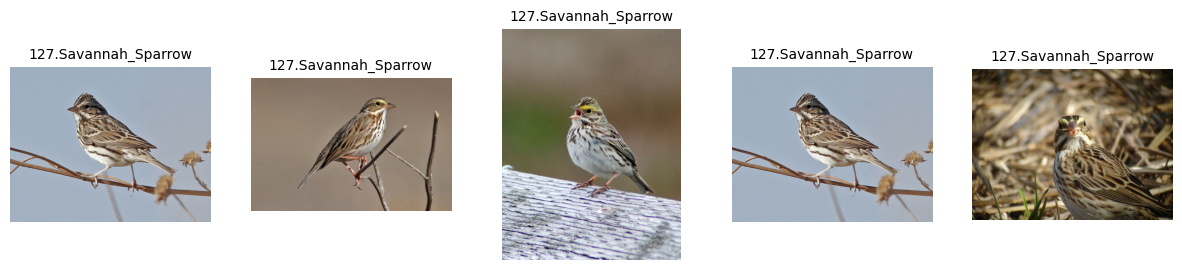

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset directory: the directory containing the "images" folder
data_dir = r'D:\DS_542_project\CUB_200_2011\images'

# List all classes (subfolders)
classes = os.listdir(data_dir)
print(f"Total {len(classes)} classes")

# Randomly select a class and display a few images from that class
random_class = random.choice(classes)
class_dir = os.path.join(data_dir, random_class)
image_files = os.listdir(class_dir)
print(f"There are {len(image_files)} images in class {random_class}")

# Randomly display 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    img_path = os.path.join(class_dir, random.choice(image_files))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(random_class, fontsize=10)
    ax.axis('off')
plt.show()


In [2]:
import os
import shutil

# Base directory where the dataset is located
base_dir = r'D:\DS_542_project\CUB_200_2011'
images_dir = os.path.join(base_dir, 'images')
# Output directory to store the organized dataset
output_dir = os.path.join(base_dir, 'organized')
os.makedirs(output_dir, exist_ok=True)

# Define paths for the annotation files
images_file = os.path.join(base_dir, 'images.txt')
split_file = os.path.join(base_dir, 'train_test_split.txt')

# Create train and test directories
train_dir = os.path.join(output_dir, 'train')
test_dir = os.path.join(output_dir, 'test')
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Step 1: Read images.txt to build a mapping from image id to file path
id_to_path = {}
with open(images_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            image_id, rel_path = parts
            id_to_path[image_id] = rel_path

# Step 2: Read train_test_split.txt and copy images to the appropriate folder
with open(split_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            image_id, is_train = parts
            # Retrieve the relative file path from images.txt
            rel_path = id_to_path.get(image_id)
            if rel_path:
                # Extract the class name (the first part of the path, e.g., "001.Black_footed_Albatross")
                class_name = rel_path.split('/')[0]
                # Determine source file path
                src_path = os.path.join(images_dir, rel_path)
                # Determine destination directory based on the split
                if is_train == '1':
                    dst_dir = os.path.join(train_dir, class_name)
                else:
                    dst_dir = os.path.join(test_dir, class_name)
                # Create the class folder in the destination if it doesn't exist
                os.makedirs(dst_dir, exist_ok=True)
                # Copy the file
                shutil.copy(src_path, dst_dir)

print("Dataset organized into train and test folders!")


Dataset organized into train and test folders!


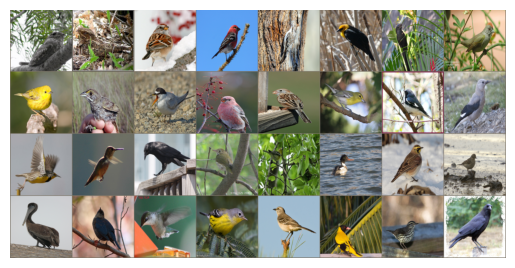

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Paths to the organized dataset
train_dir = r'D:\DS_542_project\CUB_200_2011\organized\train'
test_dir  = r'D:\DS_542_project\CUB_200_2011\organized\test'

# Define transforms for training and testing
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform_train)
test_dataset  = torchvision.datasets.ImageFolder(test_dir, transform=transform_test)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Optional: Visualize a batch of training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Function to unnormalize and show images
def imshow(img):
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.clamp(0, 1)
    npimg = img.numpy().transpose((1, 2, 0))
    plt.imshow(npimg)
    plt.axis('off')
    plt.show()

# Display the images in a grid
imshow(torchvision.utils.make_grid(images))


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define paths to your organized dataset
train_dir = r'D:\DS_542_project\CUB_200_2011\organized\train'
test_dir  = r'D:\DS_542_project\CUB_200_2011\organized\test'

# Define transforms for training and testing
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Create datasets using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform_train)
test_dataset  = torchvision.datasets.ImageFolder(test_dir, transform=transform_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Load a pretrained ResNet50 and modify the final layer for 200 classes
model = models.resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 200)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10  # Set number of training epochs

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

    # Evaluate on the test set after each epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

print("Training complete!")


Using device: cuda


c:\Users\27435\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\27435\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 188/188 [00:28<00:00,  6.56it/s]


Epoch 1/10, Loss: 4.0134
Test Accuracy: 0.4522


Epoch 2/10: 100%|██████████| 188/188 [00:33<00:00,  5.61it/s]


Epoch 2/10, Loss: 1.9361
Test Accuracy: 0.6003


...

Epoch 8/10, Loss: 0.1070
Test Accuracy: 0.6924


Epoch 9/10: 100%|██████████| 188/188 [00:36<00:00,  5.17it/s]


Epoch 9/10, Loss: 0.0776
Test Accuracy: 0.7375


Epoch 10/10: 100%|██████████| 188/188 [00:35<00:00,  5.29it/s]


Epoch 10/10, Loss: 0.0514
Test Accuracy: 0.7295
Training complete!


### Further Tunning

CUDA is available. Using GPU.
Using device: cuda
Attempting to load datasets from: organized
Error: Training directory not found: organized\train. Please ensure the 'organized/train' and 'organized/test' directories exist and contain the images.

Starting training...



Epoch 1/20, Train Loss: 3.9878


Epoch 1 finished in 50.65s. Val Loss: 2.5137, Test Accuracy: 0.4413, LR: 0.000100



Epoch 2/20, Train Loss: 1.9206


Epoch 2 finished in 50.00s. Val Loss: 1.5349, Test Accuracy: 0.6189, LR: 0.000100


...


Epoch 19/20, Train Loss: 0.0226


Epoch 19 finished in 43.48s. Val Loss: 0.8696, Test Accuracy: 0.7673, LR: 0.000001



Epoch 20/20, Train Loss: 0.0219


Epoch 20 finished in 42.48s. Val Loss: 0.8699, Test Accuracy: 0.7644, LR: 0.000001

Training complete!


AttributeError: 'StepLR' object has no attribute 'get_lr_at_epoch'

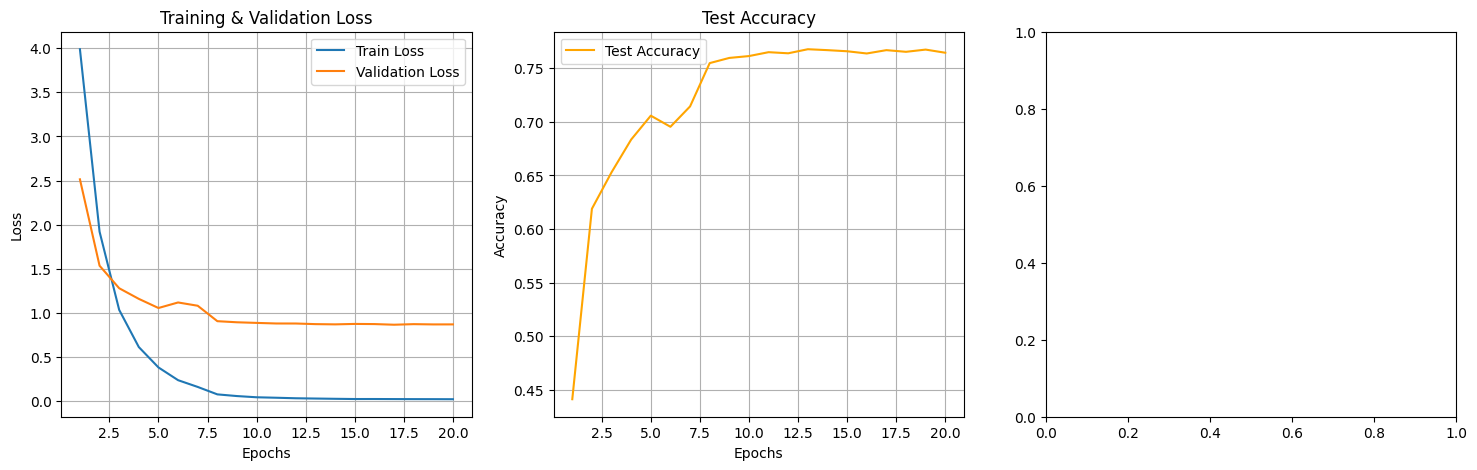

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR # Import StepLR
from tqdm import tqdm
import matplotlib.pyplot as plt # Added for potential plotting later
import time # Added for timing epochs
import os # Added for path joining

# --- Configuration ---
# Define paths to your organized dataset (Ensure these are correct for your system)
# It's good practice to define paths at the beginning
# Trying a relative path approach assuming 'organized' dir is in the same place as the notebook might run
# If this fails, replace with your absolute path like r'D:\DS_542_project\CUB_200_2011\organized'
base_dir = 'organized'
train_dir = os.path.join(base_dir, 'train')
test_dir  = os.path.join(base_dir, 'test')

# Training Hyperparameters
num_epochs = 20 # Increased epochs
batch_size = 32
learning_rate = 1e-4
lr_step_size = 7 # Scheduler step size (adjust as needed)
lr_gamma = 0.1 # Scheduler gamma (multiplicative factor)
num_classes = 200
num_workers = 0 # Set to 0 to avoid multiprocessing issues in some environments, adjust if needed

# --- Device Setup ---
# Attempt to use CUDA, fall back to CPU if unavailable or fails
try:
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("CUDA is available. Using GPU.")
    else:
        device = torch.device("cpu")
        print("CUDA not available. Using CPU.")
except Exception as e:
    print(f"Error setting device, likely CUDA issue: {e}. Defaulting to CPU.")
    device = torch.device("cpu")

print(f"Using device: {device}")


# --- Data Transforms ---
# Enhanced Training Transforms
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # More robust cropping
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Add color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Testing Transforms (usually simpler)
transform_test = transforms.Compose([
    transforms.Resize(256), # Resize slightly larger
    transforms.CenterCrop(224), # Then center crop
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- Datasets and DataLoaders ---
# Use a try-except block to handle potential dataset loading errors gracefully
try:
    print(f"Attempting to load datasets from: {base_dir}")
    # Check if directories exist
    if not os.path.isdir(train_dir):
        raise FileNotFoundError(f"Training directory not found: {train_dir}")
    if not os.path.isdir(test_dir):
        raise FileNotFoundError(f"Test directory not found: {test_dir}")

    train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform_train)
    test_dataset  = torchvision.datasets.ImageFolder(test_dir, transform=transform_test)

    # Check if datasets loaded correctly
    if len(train_dataset) == 0:
        print(f"Warning: Training dataset loaded but is empty. Check {train_dir}")
    if len(test_dataset) == 0:
        print(f"Warning: Test dataset loaded but is empty. Check {test_dir}")


    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True if device.type=='cuda' else False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True if device.type=='cuda' else False)
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Test dataset size: {len(test_dataset)}")
    print(f"Number of classes found: {len(train_dataset.classes)}")
    # Add a check for the number of classes
    if len(train_dataset.classes) != num_classes:
         print(f"Warning: Expected {num_classes} classes, but found {len(train_dataset.classes)}.")
         # Adjust num_classes if needed, or investigate dataset structure
         # num_classes = len(train_dataset.classes) # Uncomment to automatically adjust

except FileNotFoundError as fnf_error:
    print(f"Error: {fnf_error}. Please ensure the 'organized/train' and 'organized/test' directories exist and contain the images.")
    exit()
except Exception as e:
    print(f"An error occurred loading the dataset: {e}")
    exit()

# --- Model Setup ---
# Load a pretrained ResNet50 and modify the final layer
# Using the recommended weights parameter
try:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
except Exception as e:
    print(f"Error loading pretrained model: {e}")
    print("Attempting to load without pretrained weights (will train from scratch).")
    model = models.resnet50(weights=None) # Load architecture only

# Freeze early layers (optional, but common for fine-tuning)
# Uncomment the following lines if you want to freeze layers
# print("Freezing initial layers...")
# for name, param in model.named_parameters():
#     if "fc" not in name: # Don't freeze the final layer
#         param.requires_grad = False
#     else:
#         param.requires_grad = True # Ensure the final layer is trainable


# Modify final layer
try:
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
except Exception as e:
    print(f"Error modifying the final layer (fc): {e}")
    print("Ensure the model architecture is as expected (e.g., ResNet50).")
    exit()


model = model.to(device)

# Verify which parameters are trainable
# print("\nTrainable parameters:")
# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(name)

# --- Loss Function and Optimizer ---
criterion = nn.CrossEntropyLoss()
# If fine-tuning only the head, adjust the optimizer accordingly:
# optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)
# If fine-tuning all layers:
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5) # Added weight decay

# --- Learning Rate Scheduler ---
scheduler = StepLR(optimizer, step_size=lr_step_size, gamma=lr_gamma)

# --- Training Loop ---
train_losses = []
test_accuracies = []
val_losses = [] # Added validation loss tracking

print("\nStarting training...")
# Check if DataLoader is empty before starting
if len(train_loader) == 0 or len(test_loader) == 0:
    print("Error: DataLoaders are empty. Cannot start training. Check dataset paths and structure.")
    exit()


for epoch in range(num_epochs):
    epoch_start_time = time.time()
    model.train() # Set model to training mode
    running_loss = 0.0

    # Training loop with progress bar
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]", leave=False)
    for i, (inputs, labels) in enumerate(pbar):
        inputs = inputs.to(device, non_blocking=True) # Use non_blocking for potential speedup
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Handle potential NaN loss
        if torch.isnan(loss):
            print(f"Warning: NaN loss detected at epoch {epoch+1}, batch {i}. Skipping batch.")
            continue # Skip this batch update

        loss.backward()
        # Gradient clipping (optional, can help stabilize training)
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item()) # Show current batch loss

    epoch_loss = running_loss / len(train_dataset) if len(train_dataset) > 0 else 0
    train_losses.append(epoch_loss)
    print(f"\nEpoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}")

    # --- Validation Loop ---
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    val_loss_epoch = 0.0 # Use a different variable name for epoch validation loss
    pbar_test = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]", leave=False)
    with torch.no_grad():
        for inputs, labels in pbar_test:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels) # Calculate validation loss
            val_loss_epoch += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            pbar_test.set_postfix(acc=correct/total if total > 0 else 0)

    accuracy = correct / total if total > 0 else 0
    epoch_val_loss = val_loss_epoch / len(test_dataset) if len(test_dataset) > 0 else 0
    test_accuracies.append(accuracy)
    val_losses.append(epoch_val_loss) # Store validation loss

    # Step the scheduler based on validation loss (optional alternative)
    # scheduler.step(epoch_val_loss)
    # Or step based on epoch number (as originally planned)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr'] # More robust way to get LR

    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time

    print(f"Epoch {epoch+1} finished in {epoch_duration:.2f}s. Val Loss: {epoch_val_loss:.4f}, Test Accuracy: {accuracy:.4f}, LR: {current_lr:.6f}")


print("\nTraining complete!")

# --- Plotting (Optional but Recommended) ---
# Plot training and validation loss, and test accuracy
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)


plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.grid(True)
plt.legend()

# Show learning rate changes
lrs = [group['lr'] for group in optimizer.param_groups] # Get LR history (approximate if scheduler was stepped mid-epoch before)
plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), [scheduler.get_lr_at_epoch(ep) for ep in range(num_epochs)], label='Learning Rate', color='green') # Plot scheduled LR
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True)
plt.legend()


plt.tight_layout()
plt.show()


# --- Save Model (Optional) ---
# Consider saving the model with the best validation accuracy
# You'll need to track the best accuracy and corresponding epoch during training
# Example:
# best_acc = 0.0
# ... inside the loop ...
# if accuracy > best_acc:
#     best_acc = accuracy
#     torch.save(model.state_dict(), 'resnet50_baseline_best.pth')
#     print(f"New best model saved with accuracy: {best_acc:.4f}")

# Or save the final model:
# torch.save(model.state_dict(), 'resnet50_baseline_refined_final.pth')
# print("Final model state dict saved.")

CUDA is available. Using GPU.
Using device: cuda
Attempting to load datasets from: organized
Error: Training directory not found: organized\train.
Creating ResNet50-CBAM model instance...
Loading base ResNet50 model...
Creating new ResNet50 structure with CBAM blocks...
Copying compatible weights...
ResNet50-CBAM model structure created and pretrained weights copied.

Starting training...



Epoch 1/20, Train Loss: 4.8188


Epoch 1 finished in 50.58s. Val Loss: 3.8912, Test Accuracy: 0.1683, LR: 0.000100



Epoch 2/20, Train Loss: 3.1186


Epoch 2 finished in 36.36s. Val Loss: 2.5143, Test Accuracy: 0.3523, LR: 0.000100


...


Epoch 19/20, Train Loss: 0.0463


Epoch 19 finished in 65.93s. Val Loss: 0.9964, Test Accuracy: 0.7318, LR: 0.000001



Epoch 20/20, Train Loss: 0.0470


c:\Users\27435\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 20 finished in 69.10s. Val Loss: 0.9919, Test Accuracy: 0.7344, LR: 0.000001

Training complete!
Generating plots...


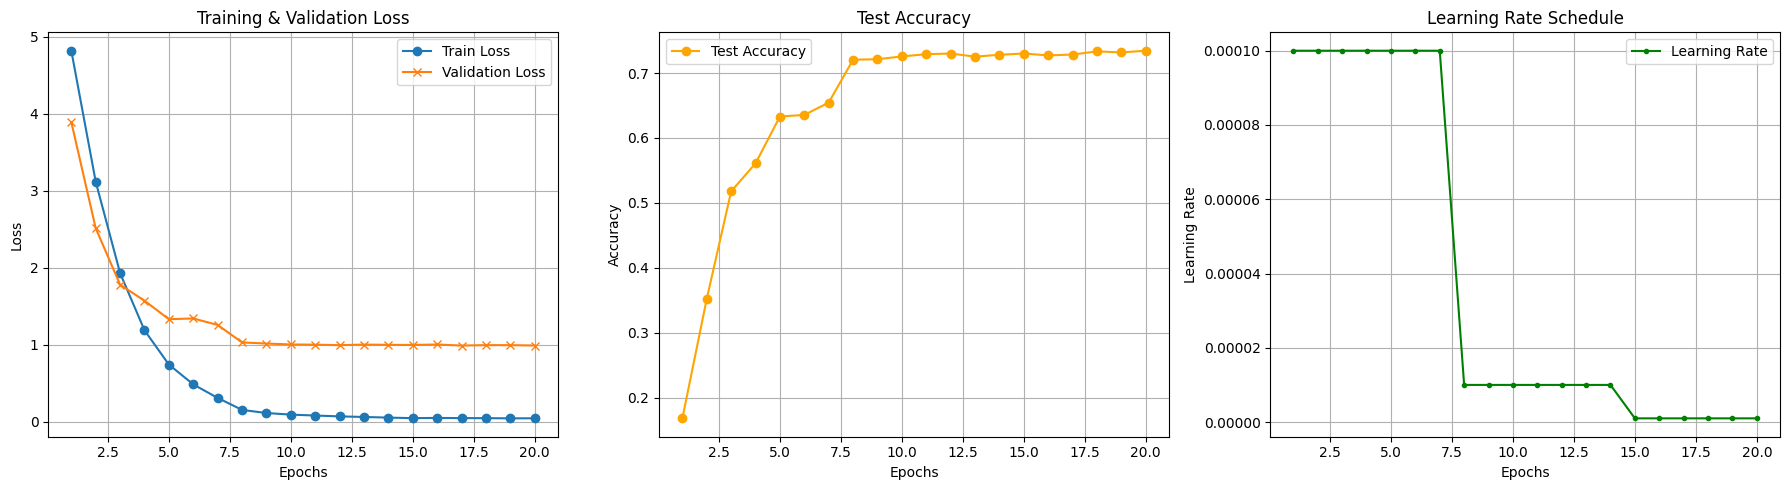

: 

In [ ]:
# --- Essential Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models.resnet import Bottleneck # Import Bottleneck
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import os

# --- Configuration ---
base_dir = 'organized'
train_dir = os.path.join(base_dir, 'train')
test_dir  = os.path.join(base_dir, 'test')
num_epochs = 20
batch_size = 32
learning_rate = 1e-4
lr_step_size = 7
lr_gamma = 0.1
num_classes = 200
num_workers = 0

# --- Device Setup ---
try:
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("CUDA is available. Using GPU.")
    else:
        device = torch.device("cpu")
        print("CUDA not available. Using CPU.")
except Exception as e:
    print(f"Error setting device, likely CUDA issue: {e}. Defaulting to CPU.")
    device = torch.device("cpu")
print(f"Using device: {device}")

# --- Data Transforms ---
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- Datasets and DataLoaders ---
try:
    print(f"Attempting to load datasets from: {base_dir}")
    if not os.path.isdir(train_dir): raise FileNotFoundError(f"Training directory not found: {train_dir}")
    if not os.path.isdir(test_dir): raise FileNotFoundError(f"Test directory not found: {test_dir}")
    train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform_train)
    test_dataset  = torchvision.datasets.ImageFolder(test_dir, transform=transform_test)
    if len(train_dataset) == 0: print(f"Warning: Training dataset loaded but is empty. Check {train_dir}")
    if len(test_dataset) == 0: print(f"Warning: Test dataset loaded but is empty. Check {test_dir}")
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True if device.type=='cuda' else False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True if device.type=='cuda' else False)
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Test dataset size: {len(test_dataset)}")
    print(f"Number of classes found: {len(train_dataset.classes)}")
    if len(train_dataset.classes) != num_classes:
         print(f"Warning: Expected {num_classes} classes, but found {len(train_dataset.classes)}.")
except FileNotFoundError as fnf_error:
    print(f"Error: {fnf_error}.")
    exit()
except Exception as e:
    print(f"An error occurred loading the dataset: {e}")
    exit()

# --- CBAM Attention Modules ---
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        x_att = self.conv1(x_cat)
        return self.sigmoid(x_att)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out

# --- Modified ResNet Bottleneck with CBAM ---
class BottleneckCBAM(Bottleneck):
    expansion = 4
    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None, reduction_ratio=16):
        super(BottleneckCBAM, self).__init__(inplanes, planes, stride, downsample, groups,
                                             base_width, dilation, norm_layer)
        self.cbam = CBAM(planes * self.expansion, ratio=reduction_ratio)
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        out = self.cbam(out) # Apply CBAM
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

# --- *** CORRECTED Function to Build ResNet50 with CBAM Blocks *** ---
def build_resnet50_cbam(pretrained=True, num_classes=200):
    print("Loading base ResNet50 model...")
    # Load the original pretrained model to copy weights from
    base_model = models.resnet50(weights=(models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None))

    print("Creating new ResNet50 structure with CBAM blocks...")
    # Create a new model structure using our modified Bottleneck block
    new_model = models.ResNet(BottleneckCBAM, [3, 4, 6, 3], num_classes=num_classes) # Use BottleneckCBAM here

    print("Copying compatible weights...")
    # Copy weights layer by layer, block by block
    new_model.conv1.load_state_dict(base_model.conv1.state_dict())
    new_model.bn1.load_state_dict(base_model.bn1.state_dict())

    for layer_name in ['layer1', 'layer2', 'layer3', 'layer4']:
        base_layer = getattr(base_model, layer_name)
        new_layer = getattr(new_model, layer_name)

        for i in range(len(base_layer)):
            if isinstance(base_layer[i], Bottleneck) and isinstance(new_layer[i], BottleneckCBAM):
                base_block = base_layer[i]
                new_block = new_layer[i]

                # Copy weights for standard layers within the block
                new_block.conv1.load_state_dict(base_block.conv1.state_dict())
                new_block.bn1.load_state_dict(base_block.bn1.state_dict())
                new_block.conv2.load_state_dict(base_block.conv2.state_dict())
                new_block.bn2.load_state_dict(base_block.bn2.state_dict())
                new_block.conv3.load_state_dict(base_block.conv3.state_dict())
                new_block.bn3.load_state_dict(base_block.bn3.state_dict())

                # Copy downsample layer weights if it exists
                if base_block.downsample is not None:
                    new_block.downsample.load_state_dict(base_block.downsample.state_dict())
            else:
                print(f"Warning: Block type mismatch or unexpected structure in {layer_name}[{i}]")

    # Redefine the final fully connected layer
    num_features = new_model.fc.in_features
    new_model.fc = nn.Linear(num_features, num_classes)

    print("ResNet50-CBAM model structure created and pretrained weights copied.")
    return new_model


# --- Model, Loss, Optimizer, Scheduler Setup ---
print("Creating ResNet50-CBAM model instance...")
try:
    model = build_resnet50_cbam(pretrained=True, num_classes=num_classes)
    model = model.to(device)
except Exception as e:
    print(f"Error creating or moving model to device: {e}")
    exit()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=lr_step_size, gamma=lr_gamma)

# --- Training Loop ---
train_losses = []
test_accuracies = []
val_losses = []

print("\nStarting training...")
if len(train_loader) == 0 or len(test_loader) == 0:
    print("Error: DataLoaders are empty. Cannot start training.")
    exit()

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    model.train()
    running_loss = 0.0
    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]", leave=False)
    for i, (inputs, labels) in enumerate(pbar_train):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        if torch.isnan(loss):
            print(f"Warning: NaN loss at epoch {epoch+1}, batch {i}. Skipping.")
            continue
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        pbar_train.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_dataset) if len(train_dataset) > 0 else 0
    train_losses.append(epoch_loss)
    print(f"\nEpoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}")

    model.eval()
    correct = 0
    total = 0
    val_loss_epoch = 0.0
    pbar_test = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]", leave=False)
    with torch.no_grad():
        for inputs, labels in pbar_test:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_epoch += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            pbar_test.set_postfix(acc=correct/total if total > 0 else 0)

    accuracy = correct / total if total > 0 else 0
    epoch_val_loss = val_loss_epoch / len(test_dataset) if len(test_dataset) > 0 else 0
    test_accuracies.append(accuracy)
    val_losses.append(epoch_val_loss)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    print(f"Epoch {epoch+1} finished in {epoch_duration:.2f}s. Val Loss: {epoch_val_loss:.4f}, Test Accuracy: {accuracy:.4f}, LR: {current_lr:.6f}")

print("\nTraining complete!")

# --- Plotting ---
print("Generating plots...")
try:
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='x')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy', color='orange', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Test Accuracy')
    plt.grid(True)
    plt.legend()

    lr_history = []
    temp_optimizer = optim.Adam([torch.zeros(1)], lr=learning_rate) # Dummy optimizer
    temp_scheduler = StepLR(temp_optimizer, step_size=lr_step_size, gamma=lr_gamma)
    for ep_num in range(num_epochs):
         # Note: Need to get LR *before* stepping for plotting the LR *used* in that epoch
         lr_history.append(temp_optimizer.param_groups[0]['lr'])
         temp_scheduler.step()

    plt.subplot(1, 3, 3)
    plt.plot(range(1, num_epochs + 1), lr_history, label='Learning Rate', color='green', marker='.')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as plot_err:
    print(f"Could not generate plots: {plot_err}")


# --- Save Final Model (Optional) ---
# model_save_path = 'resnet50_cbam_final.pth'
# try:
#     torch.save(model.state_dict(), model_save_path)
#     print(f"Final model state dict saved to {model_save_path}")
# except Exception as save_err:
#     print(f"Error saving model: {save_err}")

In [11]:
import pathlib, random, shutil

random.seed(42)
train_root = pathlib.Path(r'D:\DS_542_project\CUB_200_2011\organized\train')
val_root   = pathlib.Path(r'D:\DS_542_project\CUB_200_2011\organized\val')
val_root.mkdir(exist_ok=True)

for cls_dir in train_root.iterdir():
    images = list(cls_dir.glob('*'))
    n_val  = max(1, int(0.1 * len(images)))     # 10 % or at least 1 image
    val_samples = random.sample(images, n_val)

    (val_root / cls_dir.name).mkdir(exist_ok=True)
    for img in val_samples:
        shutil.move(str(img), val_root / cls_dir.name / img.name)
import torch, torchvision, torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import MulticlassAccuracy
import matplotlib.pyplot as plt
from pathlib import Path
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ImageNet statistics (fine for CUB birds)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02,0.15)),
    transforms.Normalize(mean, std),
])

val_tfms = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean, std),
])

data_root = Path(r'D:\DS_542_project\CUB_200_2011\organized')
train_ds  = datasets.ImageFolder(data_root/'train', transform=train_tfms)
val_ds    = datasets.ImageFolder(data_root/'val',   transform=val_tfms)
test_ds   = datasets.ImageFolder(data_root/'test',  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

n_classes = len(train_ds.classes)
print(f'{n_classes} bird species, {len(train_ds)} train, {len(val_ds)} val, {len(test_ds)} test')
from cbam_resnet import resnet50_cbam   # your helper

model = resnet50_cbam(pretrained=True, num_classes=n_classes)
model.to(device)
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler  = ReduceLROnPlateau(optimizer, mode='min', factor=0.3,
                               patience=3, verbose=True)
metric_acc = MulticlassAccuracy(num_classes=n_classes).to(device)
best_val, patience, wait = 1e9, 7, 0

for epoch in range(1, 21):
    # ---- train ----
    model.train()
    running_loss = 0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.)
        optimizer.step()
        running_loss += loss.item()*x.size(0)

    # ---- validate ----
    model.eval()
    val_loss, val_acc = 0, 0
    metric_acc.reset()
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()*x.size(0)
            metric_acc.update(out, y)
    val_loss /= len(val_ds)
    val_acc   = metric_acc.compute().item()

    scheduler.step(val_loss)   # should come AFTER optimizer.step()

    print(f'E{epoch:02d}  train-loss={running_loss/len(train_ds):.3f}  '
          f'val-loss={val_loss:.3f}  val-acc={val_acc:.3f}  lr={optimizer.param_groups[0]["lr"]:.2e}')

    # ---- early stopping ----
    if val_loss < best_val:
        best_val, wait = val_loss, 0
        torch.save(model.state_dict(), 'best.pt')
    else:
        wait += 1
        if wait >= patience:
            print('Early stopping triggered')
            break
model.load_state_dict(torch.load('best.pt'))
model.eval()
metric_acc.reset()

all_preds, all_labels = [], []
with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        metric_acc.update(out, y)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())

test_acc = metric_acc.compute().item()
print(f'★  test accuracy = {test_acc:.3f}')

# Confusion matrix (optional diagnostics)
import seaborn as sns, numpy as np
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(torch.cat(all_labels), torch.cat(all_preds), normalize='true')
plt.figure(figsize=(8,6)); sns.heatmap(cm, cmap='Blues', cbar=False); plt.title('Confusion matrix'); plt.show()


200 bird species, 5400 train, 594 val, 5794 test


ModuleNotFoundError: No module named 'cbam_resnet'

In [14]:
from pathlib import Path

# search for any folder whose name starts with "CUB"
matches = list(Path('.').rglob('CUB_200*'))
if matches:
    print("Found dataset folders at:")
    for p in matches:
        print("  ", p.resolve())
else:
    print("No CUB_200_2011 folder found under the notebook's directory.")


No CUB_200_2011 folder found under the notebook's directory.


In [16]:
# replace the existing DATA_ROOT line with:
DATA_ROOT = r'D:\DS_542_project\CUB_200_2011'


In [17]:
from pathlib import Path

matches = list(Path('.').rglob('CUB_200*'))
if matches:
    print("Found dataset folders at:")
    for p in matches:
        print("  ", p.resolve())
else:
    print("No CUB_200_2011 folder found under the notebook's directory.")


No CUB_200_2011 folder found under the notebook's directory.
